# Explore EarthCARE Data Structure

Inspect the internal structure of EarthCARE L2 products to understand
dimensions, variables, and coordinate systems before conversion.

In [1]:
import earthcarekit as eck
import numpy as np
import xarray as xr

ORBIT = "06109D"

## MSI products (2D swath)

MSI has `(along_track, across_track)` dimensions with 2D lat/lon arrays — similar to Sentinel-3 OLCI/SLSTR.

In [2]:
for file_type in ["MSI_CM__2A", "MSI_COP_2A", "MSI_AOT_2A"]:
    try:
        result = eck.search_product(file_type=file_type, orbit_and_frame=ORBIT)
        with eck.read_product(result.filepath[0]) as ds:
            print(f"\n{'='*60}")
            print(f"{file_type}")
            print(f"{'='*60}")
            print(f"Dimensions: {dict(ds.sizes)}")
            print(f"\n2D variables (along_track, across_track):")
            for v in ds.data_vars:
                if ds[v].dims == ("along_track", "across_track"):
                    vals = ds[v].values
                    fill = -128 if vals.dtype == np.int8 else None
                    if fill is not None:
                        valid = vals[vals != fill]
                    elif vals.dtype in (np.float32, np.float64):
                        valid = vals[np.isfinite(vals)]
                    else:
                        valid = vals.ravel()
                    n_valid = len(valid)
                    if n_valid > 0:
                        print(f"  {v}: dtype={vals.dtype}, valid={n_valid}, range=[{valid.min():.3f}, {valid.max():.3f}]")
                    else:
                        print(f"  {v}: dtype={vals.dtype}, ALL FILL")
    except Exception as e:
        print(f"\n{file_type}: not available ({e})")


MSI_CM__2A
Dimensions: {'along_track': 11216, 'across_track': 357}

2D variables (along_track, across_track):
  latitude_swath: dtype=float64, valid=4004112, range=[22.291, 67.620]
  longitude_swath: dtype=float64, valid=4004112, range=[-0.939, 19.344]
  quality_status: dtype=int8, valid=4004112, range=[0.000, 3.000]
  cloud_mask: dtype=int8, valid=3987502, range=[0.000, 3.000]
  cloud_type: dtype=int8, valid=3981555, range=[0.000, 9.000]
  cloud_phase: dtype=int8, valid=954386, range=[1.000, 3.000]
  surface_classification: dtype=int16, valid=4004112, range=[-32765.000, -32509.000]
  cloud_mask_quality_status: dtype=int8, valid=4004112, range=[8.000, 16.000]
  cloud_type_quality_status: dtype=int8, valid=3981555, range=[2.000, 16.000]
  cloud_phase_quality_status: dtype=int8, valid=4004112, range=[-127.000, 16.000]
  plot_surface_classification: dtype=float64, valid=4004112, range=[1.000, 8.000]
  plot_cloud_mask_quality_status: dtype=float64, valid=4004112, range=[3.000, 4.000]
  pl

## ATLID/CPR products (1D profiles)

Profile instruments have `(along_track,)` lat/lon with a `vertical` dimension for atmospheric columns.

In [3]:
for file_type in ["ATL_AER_2A"]:
    try:
        result = eck.search_product(file_type=file_type, orbit_and_frame=ORBIT)
        with eck.read_product(result.filepath[0]) as ds:
            print(f"\n{'='*60}")
            print(f"{file_type}")
            print(f"{'='*60}")
            print(f"Dimensions: {dict(ds.sizes)}")
            print(f"Lat: shape={ds['latitude'].shape}, range=[{float(ds['latitude'].min()):.1f}, {float(ds['latitude'].max()):.1f}]")
            print(f"Lon: shape={ds['longitude'].shape}, range=[{float(ds['longitude'].min()):.1f}, {float(ds['longitude'].max()):.1f}]")
            print(f"\n2D variables (along_track, vertical):")
            for v in ds.data_vars:
                if ds[v].dims == ("along_track", "vertical"):
                    print(f"  {v}: shape={ds[v].shape}, dtype={ds[v].dtype}")
    except Exception as e:
        print(f"\n{file_type}: not available ({e})")


ATL_AER_2A
Dimensions: {'along_track': 5144, 'vertical': 242, 'layer': 25, 'class': 7}
Lat: shape=(5144,), range=[22.5, 67.5]
Lon: shape=(5144,), range=[-0.6, 16.7]

2D variables (along_track, vertical):
  height: shape=(5144, 242), dtype=float32
  range: shape=(5144, 242), dtype=float32
  simple_classification: shape=(5144, 242), dtype=int8
  mie_detection_status: shape=(5144, 242), dtype=int8
  rayleigh_detection_status: shape=(5144, 242), dtype=int8
  horizontal_averaging_mask: shape=(5144, 242), dtype=int32
  internal_lidar_feature_mask: shape=(5144, 242), dtype=int8
  extended_data_quality_status: shape=(5144, 242), dtype=int8
  quality_status: shape=(5144, 242), dtype=int8
  particle_extinction_coefficient_355nm: shape=(5144, 242), dtype=float32
  particle_extinction_coefficient_355nm_error: shape=(5144, 242), dtype=float32
  particle_backscatter_coefficient_355nm: shape=(5144, 242), dtype=float32
  particle_backscatter_coefficient_355nm_error: shape=(5144, 242), dtype=float32
 

## Visualize ground tracks

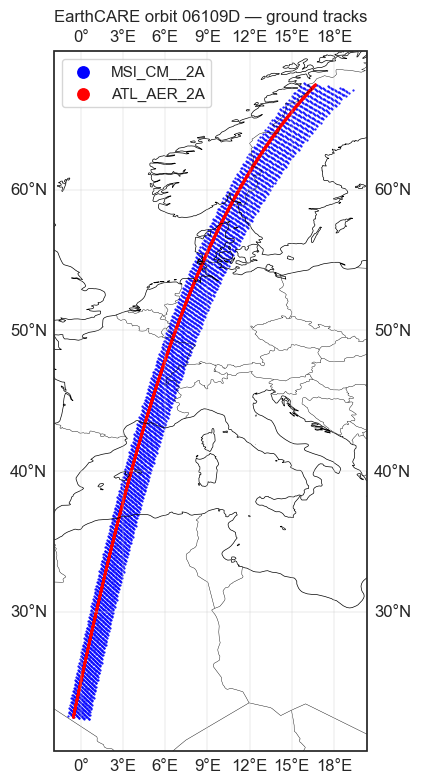

In [4]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3)

colors = {"MSI_CM__2A": "blue", "ATL_AER_2A": "red"}

for file_type, color in colors.items():
    try:
        result = eck.search_product(file_type=file_type, orbit_and_frame=ORBIT)
        with eck.read_product(result.filepath[0]) as ds:
            if "latitude_swath" in ds:
                lat = ds["latitude_swath"].values
                lon = ds["longitude_swath"].values
            else:
                lat = ds["latitude"].values
                lon = ds["longitude"].values
            step = max(1, lat.size // 5000)
            ax.scatter(lon.ravel()[::step], lat.ravel()[::step],
                       s=0.3, color=color, label=file_type, transform=ccrs.PlateCarree())
    except Exception:
        pass

ax.legend(markerscale=15)
ax.set_title(f"EarthCARE orbit {ORBIT} — ground tracks")
plt.tight_layout()
plt.show()